# Lab 01 — Working with Increasingly Large Datasets

In this notebook, we will investigate how dataset size affects data processing in Python using pandas, csv, parquet and chunck processing.

We will:

- Create an artificial healthcare dataset.
- Increase the number of observations progressively.
- Measure file size, memory usage, and execution time.
- Compare CSV and Parquet.
- Explore the limitations of loading complete datasets into pandas.
- Process large files in chunks.
- Compare the results and performance of different approaches.

> **Important:** The goal is not to find a universal maximum number of rows for pandas. The practical limit depends on the computer, available memory, data types, and operation being performed.


## 1. The central question

Imagine that a healthcare organization gives us a dataset containing information about millions of encounters.

We want to answer questions such as:

- What is the average treatment cost?
- Which medical conditions are most common?
- How many encounters belong to each hospital?
- How can we process the data if it becomes too large to load comfortably into memory?

The central question is:

> **How does the way we store and process data affect the amount of data we can work with?**

We will investigate this question experimentally rather than relying only on theoretical explanations.


## 2. Import the required libraries

For this notebook we will use the following libraries:

- `pandas` for tabular data processing.
- `numpy` for efficient numerical data generation.
- `matplotlib` for visualizing measurements.
- `time` for execution-time measurements.
- `os` and `pathlib` for file-size and path operations.
- `gc` for explicitly releasing objects during the experiment.
- `platform` for recording basic information about the execution environment.


In [1]:
import gc
import os
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 3. Record the execution environment

The results of this experiment depend on the computer and software environment.

Run the following cell to record basic information about the environment.


In [2]:
print(f"Python version: {platform.python_version()}")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Operating system: {platform.system()} {platform.release()}")


Python version: 3.11.9
pandas version: 2.2.1
NumPy version: 1.24.3
Operating system: Windows 10


## 4. Create a working directory

All generated files will be stored in a folder named `large_data_lab`.

The folder will be created relative to the location of this notebook.


In [3]:
DATA_DIR = Path("large_data_lab")
DATA_DIR.mkdir(exist_ok=True)

print(f"Working directory: {DATA_DIR.resolve()}")


Working directory: C:\Users\danie\Downloads\large_data_lab


## 5. Generate a small synthetic healthcare dataset

We will create a dataset in which each row represents a healthcare encounter.

The dataset contains:

| Variable | Description |
|---|---|
| `encounter_id` | Unique encounter identifier |
| `patient_id` | Patient identifier |
| `age` | Patient age |
| `medical_condition` | Main medical condition |
| `admission_date` | Date of admission |
| `length_of_stay` | Number of days in hospital |
| `treatment_cost` | Cost associated with treatment |
| `hospital_id` | Hospital identifier |
| `discharge_status` | Discharge outcome |

The data is artificial and should not be interpreted as real patient information.


In [4]:
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

CONDITIONS = np.array([
    "Diabetes",
    "Asthma",
    "Arthritis",
    "Cancer",
    "Infection",
    "Cardiovascular disease",
    "Fracture",
    "Neurological disorder"
])

DISCHARGE_STATUSES = np.array([
    "Home",
    "Transfer",
    "Rehabilitation",
    "Deceased"
])


## 6. Create a reusable dataset generator

The function below allows us to generate datasets with different numbers of rows.

We deliberately include different data types:

- Integers
- Floating-point numbers
- Strings
- Dates

This makes the experiment more realistic because different data types have different memory requirements.


In [5]:
def generate_healthcare_dataset(n_rows, seed=42):
    """Generate a synthetic healthcare dataset with n_rows observations."""
    local_rng = np.random.default_rng(seed)

    start_date = np.datetime64("2020-01-01")
    admission_offsets = local_rng.integers(0, 365 * 5, size=n_rows)

    return pd.DataFrame({
        "encounter_id": np.arange(1, n_rows + 1, dtype=np.int64),
        "patient_id": local_rng.integers(1, 500_001, size=n_rows, dtype=np.int64),
        "age": local_rng.integers(18, 91, size=n_rows, dtype=np.int16),
        "medical_condition": local_rng.choice(CONDITIONS, size=n_rows),
        "admission_date": start_date + admission_offsets.astype("timedelta64[D]"),
        "length_of_stay": local_rng.integers(1, 31, size=n_rows, dtype=np.int16),
        "treatment_cost": np.round(
            local_rng.uniform(100, 25_000, size=n_rows), 2
        ),
        "hospital_id": local_rng.integers(1, 101, size=n_rows, dtype=np.int16),
        "discharge_status": local_rng.choice(DISCHARGE_STATUSES, size=n_rows)
    })


## 7. Generate the first dataset

We begin with 1,000 observations.

At this size, the dataset should be easy to inspect and process.


In [6]:
df = generate_healthcare_dataset(1_000)

df.head()


,encounter_id,patient_id,age,medical_condition,admission_date,length_of_stay,treatment_cost,hospital_id,discharge_status
0,1,404151,29,Cardiovascular disease,2020-06-11,10,21084.03,59,Home
1,2,368353,82,Diabetes,2023-11-13,2,11215.10,62,Deceased
2,3,279159,44,Fracture,2023-04-09,25,23829.08,84,Rehabilitation
3,4,443202,22,Diabetes,2022-03-11,20,16304.79,83,Rehabilitation
4,5,64134,87,Diabetes,2022-03-01,21,2985.88,81,Transfer


In [7]:
df.shape


(1000, 9)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype        
---  ------             --------------  -----        
 0   encounter_id       1000 non-null   int64        
 1   patient_id         1000 non-null   int64        
 2   age                1000 non-null   int16        
 3   medical_condition  1000 non-null   object       
 4   admission_date     1000 non-null   datetime64[s]
 5   length_of_stay     1000 non-null   int16        
 6   treatment_cost     1000 non-null   float64      
 7   hospital_id        1000 non-null   int16        
 8   discharge_status   1000 non-null   object       
dtypes: datetime64[s](1), float64(1), int16(3), int64(2), object(2)
memory usage: 52.9+ KB


### Question 1

How many rows and columns does the dataset contain?

What are the main data types used in the DataFrame?


## 8. Inspect the data

Before focusing on performance, we should verify that the generated dataset has the expected structure.


In [9]:
df.describe(include="all")


,encounter_id,patient_id,age,medical_condition,admission_date,length_of_stay,treatment_cost,hospital_id,discharge_status
count,1000.000000,1000.000000,1000.00000,1000,1000,1000.000000,1000.000000,1000.000000,1000
unique,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,Asthma,NaN,NaN,NaN,NaN,Transfer
freq,NaN,NaN,NaN,147,NaN,NaN,NaN,NaN,255
mean,500.500000,248378.524000,53.46100,NaN,2022-07-06 11:19:40,15.292000,12372.548970,49.169000,NaN
min,1.000000,617.000000,18.00000,NaN,2020-01-08 00:00:00,1.000000,124.650000,1.000000,NaN
25%,250.750000,123015.750000,37.00000,NaN,2021-03-28 18:00:00,7.000000,6193.792500,24.000000,NaN
50%,500.500000,246819.000000,52.00000,NaN,2022-07-12 00:00:00,15.000000,12436.570000,48.000000,NaN
75%,750.250000,376121.250000,71.00000,NaN,2023-10-15 06:00:00,23.000000,18673.377500,75.000000,NaN
max,1000.000000,499372.000000,90.00000,NaN,2024-12-28 00:00:00,30.000000,24994.160000,100.000000,NaN


In [10]:
df["medical_condition"].value_counts()


medical_condition
Asthma                    147
Fracture                  138
Cancer                    137
Neurological disorder     132
Infection                 120
Cardiovascular disease    110
Diabetes                  108
Arthritis                 108
Name: count, dtype: int64

## 9. Measure DataFrame memory usage

A DataFrame occupies memory while it is being processed.

The following expression calculates the memory used by each column.


In [11]:
df.memory_usage()


Index                 132
encounter_id         8000
patient_id           8000
age                  2000
medical_condition    8000
admission_date       8000
length_of_stay       2000
treatment_cost       8000
hospital_id          2000
discharge_status     8000
dtype: int64

The default result does not always provide a complete estimate for string/object data.

For a more informative estimate, we can use `deep=True`.


In [12]:
memory_bytes = df.memory_usage(deep=True).sum()
memory_mb = memory_bytes / 1024**2

print(f"Estimated DataFrame memory usage: {memory_mb:.2f} MB")


Estimated DataFrame memory usage: 0.16 MB


### Question 2

Why is DataFrame memory usage not necessarily equal to the size of the CSV file on disk?

Think about:

- Text representation.
- Data types.
- Compression.
- Temporary objects created during processing.


## 10. Measure execution time

We will use `time.perf_counter()` to measure elapsed time.

This is useful for comparing operations performed in the same environment.


In [13]:
start = time.perf_counter()

mean_cost = df["treatment_cost"].mean()

elapsed = time.perf_counter() - start

print(f"Average treatment cost: {mean_cost:.2f}")
print(f"Execution time: {elapsed:.6f} seconds")


Average treatment cost: 12372.55
Execution time: 0.000364 seconds


## 11. Create helper functions for measurements

To compare datasets consistently, we will create functions for:

- Measuring DataFrame memory.
- Measuring file size.
- Measuring execution time.


In [14]:
def dataframe_memory_mb(dataframe):
    """Return the estimated memory usage of a DataFrame in MB."""
    return dataframe.memory_usage(deep=True).sum() / 1024**2


def file_size_mb(path):
    """Return the size of a file in MB."""
    return Path(path).stat().st_size / 1024**2


def timed_call(function, *args, **kwargs):
    """Run a function and return its result and elapsed time in seconds."""
    start = time.perf_counter()
    result = function(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed


## 12. Create datasets of increasing size

We will investigate the following sizes:

- 1,000 rows
- 10,000 rows
- 100,000 rows
- 1,000,000 rows
- 5,000,000 rows

The largest dataset is optional. If generation becomes too slow or memory becomes uncomfortable, stop the experiment and use the largest completed size.

> We will generate one dataset at a time instead of keeping all datasets in memory simultaneously.


In [15]:
DATASET_SIZES = [1_000, 10_000, 100_000, 1_000_000, 5_000_000]

measurement_rows = []


## 13. Measure the in-memory DataFrame at each size

For each size, we will record:

- Number of rows.
- Number of columns.
- DataFrame memory usage.
- Time required to generate the dataset.

The results will be stored in a list of dictionaries.


In [16]:
for n_rows in DATASET_SIZES:
    print(f"Generating {n_rows:,} rows...")

    start = time.perf_counter()
    current_df = generate_healthcare_dataset(n_rows, seed=RANDOM_SEED)
    generation_time = time.perf_counter() - start

    measurement_rows.append({
        "rows": n_rows,
        "columns": current_df.shape[1],
        "generation_time_seconds": generation_time,
        "dataframe_memory_mb": dataframe_memory_mb(current_df)
    })

    print(
        f"Memory: {dataframe_memory_mb(current_df):.2f} MB | "
        f"Generation time: {generation_time:.3f} seconds"
    )

    del current_df
    gc.collect()


Generating 1,000 rows...
Memory: 0.16 MB | Generation time: 0.005 seconds
Generating 10,000 rows...
Memory: 1.64 MB | Generation time: 0.012 seconds
Generating 100,000 rows...
Memory: 16.37 MB | Generation time: 0.096 seconds
Generating 1,000,000 rows...
Memory: 163.67 MB | Generation time: 0.991 seconds
Generating 5,000,000 rows...
Memory: 818.35 MB | Generation time: 6.340 seconds


In [17]:
size_results = pd.DataFrame(measurement_rows)
size_results


,rows,columns,generation_time_seconds,dataframe_memory_mb
0,1000,9,0.004727,0.163601
1,10000,9,0.011649,1.638215
2,100000,9,0.095920,16.367573
3,1000000,9,0.991277,163.674489
4,5000000,9,6.340084,818.354276


## 14. Visualize memory usage

A line chart helps us see how memory usage changes as the number of rows increases.


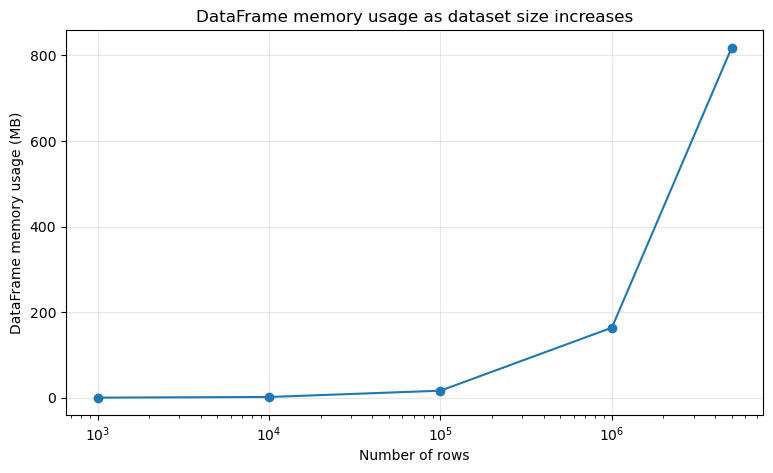

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    size_results["rows"],
    size_results["dataframe_memory_mb"],
    marker="o"
)

plt.xscale("log")
plt.xlabel("Number of rows")
plt.ylabel("DataFrame memory usage (MB)")
plt.title("DataFrame memory usage as dataset size increases")
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

The exact values depend on the generated data and the pandas version, but the general pattern should be clear:

- More rows require more memory.
- The DataFrame must be represented in memory before many pandas operations can be performed.
- A dataset that is manageable at 100,000 rows may become inconvenient at several million rows.

This is why dataset size is an important computational consideration.


## 15. Save a medium-sized dataset as CSV

We will now compare two storage formats.

First, generate a dataset with 1,000,000 rows and save it as CSV.


In [19]:
N_ROWS_COMPARISON = 1_000_000

df_comparison = generate_healthcare_dataset(
    N_ROWS_COMPARISON,
    seed=RANDOM_SEED
)

csv_path = DATA_DIR / "healthcare_1m.csv"

_, csv_write_time = timed_call(
    df_comparison.to_csv,
    csv_path,
    index=False
)

print(f"CSV path: {csv_path}")
print(f"CSV file size: {file_size_mb(csv_path):.2f} MB")
print(f"CSV write time: {csv_write_time:.3f} seconds")


CSV path: large_data_lab\healthcare_1m.csv
CSV file size: 61.40 MB
CSV write time: 8.345 seconds


## 16. Save the same dataset as Parquet

Parquet is a columnar storage format designed for efficient analytical workloads.

It can store data types and use compression more efficiently than a plain text format such as CSV.

The following cell may require a Parquet engine such as `pyarrow` or `fastparquet`.


In [20]:
parquet_path = DATA_DIR / "healthcare_1m.parquet"

try:
    _, parquet_write_time = timed_call(
        df_comparison.to_parquet,
        parquet_path,
        index=False
    )

    parquet_available = True

    print(f"Parquet path: {parquet_path}")
    print(f"Parquet file size: {file_size_mb(parquet_path):.2f} MB")
    print(f"Parquet write time: {parquet_write_time:.3f} seconds")

except ImportError:
    parquet_available = False
    parquet_write_time = np.nan

    print(
        "Parquet support is not available. "
        "Install pyarrow or fastparquet to run this section."
    )


Parquet path: large_data_lab\healthcare_1m.parquet
Parquet file size: 18.88 MB
Parquet write time: 1.237 seconds


## 17. Compare CSV and Parquet file sizes

We will compare the size of the two files.

A smaller file can reduce storage requirements and the amount of data that must be transferred.


In [21]:
format_results = pd.DataFrame({
    "format": ["CSV", "Parquet"],
    "file_size_mb": [
        file_size_mb(csv_path),
        file_size_mb(parquet_path) if parquet_available else np.nan
    ]
})

format_results


,format,file_size_mb
0,CSV,61.395137
1,Parquet,18.882014


In [22]:
if parquet_available:
    compression_ratio = (
        format_results.loc[format_results["format"] == "CSV", "file_size_mb"].iloc[0]
        /
        format_results.loc[format_results["format"] == "Parquet", "file_size_mb"].iloc[0]
    )

    print(f"CSV size / Parquet size: {compression_ratio:.2f}")
else:
    print("Compression ratio cannot be calculated without Parquet support.")


CSV size / Parquet size: 3.25


### Important distinction

A smaller Parquet file does **not** automatically mean that pandas can load an unlimited amount of data.

The file is stored efficiently on disk, but a normal `pd.read_parquet()` operation still creates a DataFrame in memory.


## 18. Compare read times

We will read the same data from CSV and Parquet.

The comparison is meaningful because both files contain the same observations and variables.


In [23]:
csv_df, csv_read_time = timed_call(
    pd.read_csv,
    csv_path
)

print(f"CSV read time: {csv_read_time:.3f} seconds")
print(f"CSV DataFrame memory: {dataframe_memory_mb(csv_df):.2f} MB")


CSV read time: 1.372 seconds
CSV DataFrame memory: 237.11 MB


In [24]:
if parquet_available:
    parquet_df, parquet_read_time = timed_call(
        pd.read_parquet,
        parquet_path
    )

    print(f"Parquet read time: {parquet_read_time:.3f} seconds")
    print(f"Parquet DataFrame memory: {dataframe_memory_mb(parquet_df):.2f} MB")
else:
    parquet_df = None
    parquet_read_time = np.nan
    print("Parquet comparison skipped.")


Parquet read time: 0.674 seconds
Parquet DataFrame memory: 163.67 MB


### Question 3

Why can the CSV and Parquet files have different sizes even though they contain exactly the same data?

Why might Parquet be faster to read for analytical workloads?

Remember that actual results depend on the dataset, compression settings, hardware, and software versions.


## 19. Compare memory after reading

The following table compares the memory required by the resulting DataFrames.

Notice that the comparison is about the in-memory representation, not the size of the original file.


In [25]:
read_results = pd.DataFrame({
    "format": ["CSV", "Parquet"],
    "read_time_seconds": [
        csv_read_time,
        parquet_read_time
    ],
    "dataframe_memory_mb": [
        dataframe_memory_mb(csv_df),
        dataframe_memory_mb(parquet_df) if parquet_available else np.nan
    ]
})

read_results


,format,read_time_seconds,dataframe_memory_mb
0,CSV,1.371631,237.107411
1,Parquet,0.674141,163.674489


### Key conclusion

> **Parquet can make storage and reading more efficient, but loading a complete Parquet file into pandas still requires memory for the resulting DataFrame.**

This distinction is essential:

- **Storage format** affects how data is stored and read.
- **Processing strategy** affects how much data is held in memory at one time.


## 20. Read only selected columns from Parquet

One of the advantages of a columnar format is that we can request only the columns required for an analysis.

For example, suppose we only need:

- `medical_condition`
- `treatment_cost`

We do not need to load all other columns.


In [26]:
if parquet_available:
    selected_df, selected_read_time = timed_call(
        pd.read_parquet,
        parquet_path,
        columns=["medical_condition", "treatment_cost"]
    )

    print(f"Read time: {selected_read_time:.3f} seconds")
    print(f"Memory: {dataframe_memory_mb(selected_df):.2f} MB")
    display(selected_df.head())
else:
    selected_df = None
    print("This example requires Parquet support.")


Read time: 0.182 seconds
Memory: 72.60 MB


,medical_condition,treatment_cost
0,Fracture,22994.21
1,Neurological disorder,10566.04
2,Infection,18775.57
3,Cancer,611.45
4,Infection,2419.06


### Question 4

Why can selecting only two columns reduce memory usage?

Would selecting columns from a CSV file provide exactly the same storage advantage? Explain your reasoning.


## 21. Demonstrate the normal pandas workflow

The normal workflow loads the entire file into memory before processing it.

For example, to calculate the average treatment cost:


In [28]:
full_df = pd.read_csv(csv_path)

full_mean_cost = full_df["treatment_cost"].mean()

print(f"Average treatment cost: {full_mean_cost:.2f}")
print(f"DataFrame memory: {dataframe_memory_mb(full_df):.2f} MB")


Average treatment cost: 12546.08
DataFrame memory: 237.11 MB


This approach is convenient and often appropriate for small and medium-sized datasets.

However, as the dataset grows, loading the complete file may become slow, consume a large amount of memory, or fail.


## 22. Introduce chunk processing

Chunk processing allows us to read and process a file in smaller portions.

Instead of loading the entire file:

```python
df = pd.read_csv("healthcare.csv")
```

we use:

```python
pd.read_csv("healthcare.csv", chunksize=100_000)
```

This returns an iterable that produces DataFrames, one chunk at a time.


In [29]:
chunk_size = 100_000

chunks = pd.read_csv(csv_path, chunksize=chunk_size)

for chunk_number, chunk in enumerate(chunks, start=1):
    print(f"Chunk {chunk_number}: {chunk.shape}")
    if chunk_number == 3:
        break


Chunk 1: (100000, 9)
Chunk 2: (100000, 9)
Chunk 3: (100000, 9)


### The main idea

```text
Large file
    |
    +--> Chunk 1 --> Process --> Discard
    |
    +--> Chunk 2 --> Process --> Discard
    |
    +--> Chunk 3 --> Process --> Discard
    |
    +--> ...
```

Only the current chunk needs to be held in memory for the processing step.


## 23. Calculate an average using chunks

We will calculate the average treatment cost in two ways:

1. By loading the entire dataset.
2. By processing the CSV file in chunks.

The results should be the same, apart from very small floating-point differences.


In [30]:
full_mean_cost = full_df["treatment_cost"].mean()

print(f"Mean using the complete DataFrame: {full_mean_cost:.10f}")


Mean using the complete DataFrame: 12546.0837113200


In [31]:
total_cost = 0.0
total_count = 0

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    total_cost += chunk["treatment_cost"].sum()
    total_count += chunk["treatment_cost"].count()

chunk_mean_cost = total_cost / total_count

print(f"Mean using chunks: {chunk_mean_cost:.10f}")
print(f"Difference: {abs(full_mean_cost - chunk_mean_cost):.12f}")


Mean using chunks: 12546.0837113200
Difference: 0.000000000002


### Why do we calculate a weighted mean?

A common mistake is to calculate the mean of each chunk and then calculate the mean of those means.

That is only correct when every chunk contains the same number of observations.

The safer approach is to combine:

- The total sum.
- The total number of valid observations.

Then:

\[
\text{Mean} = \frac{\text{Total sum}}{\text{Total count}}
\]


## 24. Measure complete-file processing versus chunk processing

We will now compare execution time for the same task.


In [32]:
def mean_cost_from_full_csv(path):
    data = pd.read_csv(path)
    return data["treatment_cost"].mean()


def mean_cost_from_chunks(path, chunksize=100_000):
    total_cost = 0.0
    total_count = 0

    for chunk in pd.read_csv(path, chunksize=chunksize):
        total_cost += chunk["treatment_cost"].sum()
        total_count += chunk["treatment_cost"].count()

    return total_cost / total_count


In [33]:
_, full_processing_time = timed_call(
    mean_cost_from_full_csv,
    csv_path
)

_, chunk_processing_time = timed_call(
    mean_cost_from_chunks,
    csv_path,
    100_000
)

processing_results = pd.DataFrame({
    "approach": ["Complete DataFrame", "Chunk processing"],
    "time_seconds": [
        full_processing_time,
        chunk_processing_time
    ]
})

processing_results


,approach,time_seconds
0,Complete DataFrame,1.462598
1,Chunk processing,1.667177


### Interpretation

Chunk processing may be slower because it performs multiple read operations and combines partial results.

However, its main advantage is **memory control**, not necessarily speed.

> **Memory efficiency and execution speed are different objectives.**


## 25. Count observations by medical condition using chunks

We can also calculate categorical frequencies incrementally.

The following code counts the number of encounters associated with each medical condition.


In [34]:
condition_counts = {}

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    partial_counts = chunk["medical_condition"].value_counts()

    for condition, count in partial_counts.items():
        condition_counts[condition] = (
            condition_counts.get(condition, 0) + count
        )

condition_counts = pd.Series(condition_counts).sort_values(ascending=False)

condition_counts


Neurological disorder     125294
Asthma                    125205
Infection                 125125
Fracture                  125058
Arthritis                 125038
Diabetes                  124975
Cardiovascular disease    124663
Cancer                    124642
dtype: int64

### Question 5

Why is it possible to combine category counts from separate chunks?

Can you think of another statistic that can be calculated by combining partial results?


## 26. Calculate average treatment cost by medical condition

This exercise combines grouping and chunk processing.

For each chunk, we calculate:

- The sum of treatment costs by condition.
- The number of observations by condition.

At the end, we combine the partial results.


In [35]:
grouped_sum = {}
grouped_count = {}

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    partial_sum = chunk.groupby("medical_condition")["treatment_cost"].sum()
    partial_count = chunk.groupby("medical_condition")["treatment_cost"].count()

    for condition, value in partial_sum.items():
        grouped_sum[condition] = grouped_sum.get(condition, 0) + value

    for condition, value in partial_count.items():
        grouped_count[condition] = grouped_count.get(condition, 0) + value

mean_cost_by_condition = (
    pd.DataFrame({
        "total_cost": pd.Series(grouped_sum),
        "count": pd.Series(grouped_count)
    })
    .assign(mean_cost=lambda data: data["total_cost"] / data["count"])
    .sort_values("mean_cost", ascending=False)
)

mean_cost_by_condition


,total_cost,count,mean_cost
Arthritis,1.572701e+09,125038,12577.780739
Diabetes,1.570690e+09,124975,12568.033487
Infection,1.572288e+09,125125,12565.738460
Fracture,1.570849e+09,125058,12560.962709
Asthma,1.570960e+09,125205,12547.099895
Cardiovascular disease,1.561870e+09,124663,12528.735913
Neurological disorder,1.567646e+09,125294,12511.739103
Cancer,1.559081e+09,124642,12508.472204


## 27. Filter records and save them incrementally

Chunk processing is not limited to calculating statistics.

We can also:

- Filter rows.
- Transform values.
- Clean data.
- Save the result to another file.

The following example keeps encounters with treatment costs above 20,000.


In [36]:
filtered_csv_path = DATA_DIR / "high_cost_encounters.csv"

if filtered_csv_path.exists():
    filtered_csv_path.unlink()

first_chunk = True
total_filtered_rows = 0

for chunk in pd.read_csv(csv_path, chunksize=100_000):
    filtered = chunk[chunk["treatment_cost"] > 20_000]
    total_filtered_rows += len(filtered)

    filtered.to_csv(
        filtered_csv_path,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )

    first_chunk = False

print(f"Filtered rows: {total_filtered_rows:,}")
print(f"Output file size: {file_size_mb(filtered_csv_path):.2f} MB")


Filtered rows: 201,134
Output file size: 12.43 MB


In [37]:
filtered_df = pd.read_csv(filtered_csv_path)

filtered_df.head()


,encounter_id,patient_id,age,medical_condition,admission_date,length_of_stay,treatment_cost,hospital_id,discharge_status
0,1,409260,76,Fracture,2020-06-11,6,22994.21,38,Transfer
1,11,369933,32,Infection,2022-08-18,7,23113.61,9,Home
2,14,193985,76,Asthma,2023-10-21,15,24557.02,4,Rehabilitation
3,17,46614,58,Neurological disorder,2022-07-25,4,22435.02,79,Deceased
4,18,382656,20,Fracture,2020-08-21,8,21522.94,77,Deceased


### Why do we use `mode="a"`?

- `mode="w"` creates a new file or overwrites an existing file.
- `mode="a"` appends to an existing file.
- We write the header only for the first chunk.

This prevents the column names from being repeated for every chunk.


## 28. Compare different chunk sizes

The chunk size is a parameter that affects the processing strategy.

We will compare several chunk sizes for the same mean-calculation task.


In [38]:
chunk_sizes = [10_000, 50_000, 100_000, 250_000, 500_000]

chunk_measurements = []

for size in chunk_sizes:
    _, elapsed = timed_call(
        mean_cost_from_chunks,
        csv_path,
        size
    )

    chunk_measurements.append({
        "chunk_size": size,
        "time_seconds": elapsed
    })

chunk_results = pd.DataFrame(chunk_measurements)

chunk_results


,chunk_size,time_seconds
0,10000,2.287120
1,50000,1.769479
2,100000,1.873646
3,250000,1.472377
4,500000,1.463354


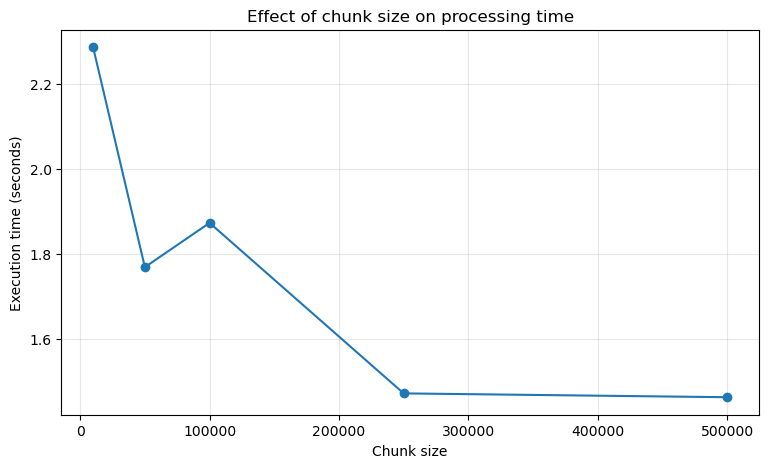

In [39]:
plt.figure(figsize=(9, 5))

plt.plot(
    chunk_results["chunk_size"],
    chunk_results["time_seconds"],
    marker="o"
)

plt.xlabel("Chunk size")
plt.ylabel("Execution time (seconds)")
plt.title("Effect of chunk size on processing time")
plt.grid(True, alpha=0.3)
plt.show()


### Interpretation

There is no universally optimal chunk size.

- Very small chunks may increase overhead because the file is read many times.
- Very large chunks may increase memory usage.
- A practical chunk size depends on the dataset, available memory, and operation.

Chunk processing is a trade-off between memory usage and processing overhead.


## 29. Optional: Process Parquet in batches

CSV has a direct `chunksize` argument in `pd.read_csv()`.

Parquet is different: it is a columnar format and is commonly processed using row groups or a library such as PyArrow.

The following optional example uses PyArrow to read Parquet in batches.


In [40]:
if parquet_available:
    try:
        import pyarrow.parquet as pq

        parquet_file = pq.ParquetFile(parquet_path)

        print(f"Number of row groups: {parquet_file.num_row_groups}")

        for batch_number, batch in enumerate(
            parquet_file.iter_batches(batch_size=100_000),
            start=1
        ):
            print(f"Batch {batch_number}: {batch.num_rows:,} rows")

            if batch_number == 3:
                break

    except ImportError:
        print(
            "PyArrow is not available. "
            "Install pyarrow to run this optional example."
        )
else:
    print("This example requires Parquet support.")


Number of row groups: 1
Batch 1: 100,000 rows
Batch 2: 100,000 rows
Batch 3: 100,000 rows


### Important distinction

CSV chunk processing and Parquet batch processing follow the same general idea:

> Read a manageable portion of the data, process it, and continue.

However, the implementation depends on the storage format and the tools being used.


## 30. Final comparison of approaches

We can summarize the approaches as follows:

| Approach | Storage format | Memory strategy | Typical use |
|---|---|---|---|
| Normal pandas | CSV | Load the complete file | Small and medium datasets |
| Normal pandas | Parquet | Load the complete file | Analytical workloads |
| Chunk processing | CSV | Load one chunk at a time | Large files |
| Batch processing | Parquet | Read selected columns or batches | Larger analytical workloads |

The best choice depends on:

- Dataset size.
- Available memory.
- Required operations.
- Storage format.
- Whether the analysis can be expressed using partial results.


## 31. Final reflection questions

Answer the following questions in your own words.

### Question 1

Why does a dataset that is small on disk still require substantial memory when loaded into pandas?

### Question 2

What are the main advantages of Parquet compared with CSV?

### Question 3

Why does Parquet not completely solve the memory problem?

### Question 4

What is chunk processing, and why is it useful?

### Question 5

Why is the mean of chunk means not always the correct overall mean?

### Question 6

What is the relationship between chunk size and execution time?

### Question 7

If you had a very large dataset and only needed three columns, what strategy would you consider?

### Question 8

When would you prefer normal pandas processing instead of chunk processing?


## 32. Final conclusions

In this notebook, we observed that:

1. Increasing the number of rows increases memory usage.
2. File size and DataFrame memory usage are different measurements.
3. CSV is simple and widely supported, but it is a text-based format.
4. Parquet is a columnar format that can reduce storage size and improve analytical reads.
5. Loading a complete Parquet file into pandas still requires memory.
6. Chunk processing allows us to process large files incrementally.
7. Chunk processing can reduce memory requirements, although it may introduce additional execution overhead.
8. The appropriate strategy depends on the dataset and the task.

> **The central lesson is that scalable data processing requires us to think about storage, memory, and computation together.**


## 33. Optional extension activities

If you want to explore the topic further, try the following activities:

1. Add a new variable containing a long text description and observe its effect on memory usage.
2. Compare the memory usage of integer columns stored as `int64` and `int16`.
3. Compare CSV and Parquet using different compression options.
4. Calculate the median treatment cost and investigate why it is more difficult to combine chunk-level results exactly.
5. Process only selected columns from a large Parquet file.
6. Increase the dataset size until the experiment becomes noticeably slow.
7. Compare the time required to filter data using a complete DataFrame and using chunks.
8. Investigate how missing values affect memory usage and chunk-based aggregation.
